# 01 Read QC

- Number of FLowcells per samples
- Raw sequencing QC, before filtering, subsampling
- QC for aggregated sequencing data per sample

In [1]:
suppressPackageStartupMessages(library(tidyverse))
library(yaml)
suppressMessages(expr = source("../scripts/00_R_presets.R"))

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


In [2]:
# Read the datasets.yml file
datasets <- read_yaml("../../data/datasets.yml")

# Parse the datasets and create a tibble
parse_datasets <- function(datasets) {
  results <- list()
  
  for (dataset_name in names(datasets)) {
    dataset <- datasets[[dataset_name]]
    
    for (seq_type in names(dataset)) {
      paths <- dataset[[seq_type]]
      
      # Handle single path (string) or multiple paths (list)
      if (is.character(paths)) {
        paths <- list(paths)
      }
      
      for (path in paths) {
        # Extract flowcell ID (last folder in path)
        flowcell_id <- basename(path)
        
        # Map sequence type names
        seq_type_mapped <- case_when(
          grepl("aternal", seq_type, ignore.case = TRUE) ~ "Parental",
          grepl("POREC", seq_type, ignore.case = TRUE) ~ "PoreC",
          grepl("UL", seq_type, ignore.case = TRUE) ~ "UltraLong",
          grepl("HQ", seq_type, ignore.case = TRUE) ~ "HQ",
          grepl("APK", seq_type, ignore.case = TRUE) ~ "APK",
          TRUE ~ seq_type
        )
        
        results[[length(results) + 1]] <- tibble(
          dataset = dataset_name,
          flowcell_id = flowcell_id,
          sequencing_type = seq_type_mapped,
          assembly_input = seq_type,
          path = path
        )
      }
    }
  }
  
  bind_rows(results)  

}

# Create the full tibble
datasets <- parse_datasets(datasets)

# Create publication subset (T2T00 to T2T19)
pub_samples <- c(
  "T2T_HG002",
  "T2T00",
  "T2T00_1",
  "T2T00_2",
  "T2T04",
  "T2T04_1",
  "T2T04_2",
  "T2T01",
  "T2T02",
  "T2T03",
  "T2T05",
  "T2T06",
  "T2T07",
  "T2T08",
  "T2T09",
  "T2T10",
  "T2T11",
  "T2T12",
  "T2T13",
  "T2T15",
  "T2T16",
  "T2T17",
  "T2T18",
  "T2T19"
)

datasets_pub <- datasets %>%
  filter(dataset %in% pub_samples)

datasets_pub_asm <- datasets_pub %>%
    group_by(flowcell_id) %>%
    filter(!(sequencing_type == "HQ" & any(sequencing_type == "UltraLong"))) %>%
    mutate(sequencing_type = ifelse(sequencing_type == "HQ", "LSK", sequencing_type)) %>%
    ungroup()


cat("\nSummary statistics:\n")
cat("Total data entries:", nrow(datasets), "\n")
print(table(datasets$sequencing_type))
cat("Publication relevant data types:", nrow(datasets_pub), "\n")
print(table(datasets_pub$sequencing_type))
cat("\nSequencing flowcells for publication:", nrow(datasets_pub_asm) ,"\n")
print(table(datasets_pub_asm$sequencing_type))


Summary statistics:
Total data entries: 436 

      APK        HQ  Parental     PoreC UltraLong 
        5       185         8        84       154 
Publication relevant data types: 231 

      APK        HQ  Parental     PoreC UltraLong 
        3        85         4        58        81 

Sequencing flowcells for publication: 150 

      APK       LSK  Parental     PoreC UltraLong 
        3         4         4        58        81 


In [3]:
# Function to check duplicates
check_duplicates <- function(df, dataset_name) {
  cat("Checking duplicates in:", dataset_name, "\n")
  cat("----------------------------------------\n")
  
  # Check for duplicate flowcell IDs within same dataset and sequencing type
  duplicates <- df %>%
    group_by(dataset, sequencing_type, flowcell_id) %>%
    filter(n() > 1) %>%
    arrange(dataset, sequencing_type, flowcell_id)
  
  if (nrow(duplicates) > 0) {
    cat("Found", nrow(duplicates), "duplicate entries:\n")
    print(duplicates %>% select(dataset, sequencing_type, flowcell_id, path))
  } else {
    cat("No duplicates found!\n")
  }
  
  # Check for flowcell IDs used across multiple sequencing types within same dataset
  #cat("\nFlowcells used for multiple sequencing types within same dataset:\n")
  multi_type <- df %>%
    group_by(dataset, flowcell_id) %>%
    filter(n_distinct(sequencing_type) > 1) %>%
    arrange(dataset, flowcell_id, sequencing_type)
  
  if (nrow(multi_type) > 0) {
    #cat("Found", n_distinct(multi_type$flowcell_id), "flowcells used for multiple types:\n")
    #print(multi_type %>% select(dataset, flowcell_id, sequencing_type, path))
  } else {
    cat("No flowcells shared across multiple types within same dataset.\n")
  }
  
  # Summary by sequencing type
  cat("\nDuplicate counts by sequencing type:\n")
  dup_summary <- df %>%
    group_by(sequencing_type, dataset, flowcell_id) %>%
    filter(n() > 1) %>%
    group_by(sequencing_type) %>%
    summarise(
      n_duplicate_entries = n(),
      n_unique_flowcells = n_distinct(flowcell_id),
      .groups = "drop"
    )
  
  if (nrow(dup_summary) > 0) {
    print(dup_summary)
  } else {
    cat("No duplicates by sequencing type.\n")
  }
  
  cat("\n")
}

# Check full dataset
#check_duplicates(datasets_tbl, "Full Dataset")

# Check publication dataset
check_duplicates(datasets_pub, "Publication Dataset (T2T00-T2T19)")

Checking duplicates in: Publication Dataset (T2T00-T2T19) 
----------------------------------------
No duplicates found!

Duplicate counts by sequencing type:
No duplicates by sequencing type.



In [4]:
# Load aggregated sequencing statistics for all flowcells


# Function to load aggregated stats for a single flowcell
load_aggregated_stats <- function(flowcell_id, dataset, seq_type) {
  # Construct the expected path
  if (seq_type == "APK" ){
    ext <- "apk"
  } else {
    ext <- "sup"
  } 
  stats_path <- file.path("../../data/bamstats/basecalled", ext, flowcell_id, 
                          paste0(flowcell_id, ".", ext, ".sequencing_summary.processed.txt"))
  
  if (file.exists(stats_path)) {
    tryCatch({
      df <- read_tsv(stats_path, show_col_types = FALSE) %>%
        mutate(
          flowcell_id = flowcell_id,
          dataset = dataset,
          sequencing_type = seq_type,
          .before = 1
        )
      return(df)
    }, error = function(e) {
      cat("Error reading", stats_path, ":", conditionMessage(e), "\n")
      return(NULL)
    })
  } else {
    # cat("File not found:", stats_path, "\n")
    return(NULL)
  }
}

# Load all aggregated stats for publication dataset
cat("Loading aggregated stats for publication dataset...\n")
stats_list <- list()
failed_files <- c()
success_count <- 0

for (i in 1:nrow(datasets_pub_asm)) {
  row <- datasets_pub_asm[i, ]
  result <- load_aggregated_stats(row$flowcell_id, row$dataset, row$sequencing_type)
  
  if (!is.null(result)) {
    stats_list[[length(stats_list) + 1]] <- result
    success_count <- success_count + 1
  } else {
    failed_files <- c(failed_files, row$flowcell_id)
  }
}

cat("\nLoading complete!\n")
cat("Successfully loaded:", success_count, "files\n")
cat("Failed to load:", length(failed_files), "files\n")

if (length(failed_files) > 0) {
  cat("\nFailed flowcells (", length(failed_files), "):\n", sep = "")
  print(failed_files)
}

flowcell_stats <- bind_rows(stats_list)
head(flowcell_stats)

Loading aggregated stats for publication dataset...

Loading complete!
Successfully loaded: 150 files
Failed to load: 0 files


flowcell_id,dataset,sequencing_type,yield,longest_read,bases_longer_1e5,bases_longer_2e5,reads_longer_1e6,N50
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24070LRa002_04503,T2T00,UltraLong,112447587626,1685691,7282123712,910491134,31,28950
24070LRa003_04399,T2T00,UltraLong,113914796738,1723002,37957574093,9508211394,29,67652
24070LRa004_04504,T2T00,UltraLong,98797039207,1536536,18715715530,2293521714,15,47038
24070LRa002_04850,T2T00,APK,103924528734,822510,1043245861,294617068,0,5691
24070LRa_PoreC_04921,T2T00,PoreC,103791775402,1589806,156895856,96580125,6,8850
24070LRa018_T2T00_PoreC_05375,T2T00,PoreC,68044144031,1233219,696787441,381444622,7,8751


In [5]:
# Combine all stats into one tibble

cat("Total flowcells:", n_distinct(flowcell_stats$flowcell_id), "\n")
cat("Total datasets:", n_distinct(flowcell_stats$dataset), "\n")


cat("\nStats by dataset:\n")
summary_flowcell_stats <- flowcell_stats %>% 
        group_by(dataset, sequencing_type) %>% 
        summarise(
          n_flowcells = n_distinct(flowcell_id),
          total_yield_Gb = sum(yield) / 1e9,
          mean_N50_kb = mean(N50) / 1000,
          total_bases_gt100kb_Gb = sum(bases_longer_1e5) / 1e9,
          total_bases_gt200kb_Gb = sum(bases_longer_2e5) / 1e9,
          total_reads_gt1Mb = sum(reads_longer_1e6),
          .groups = "drop"
        ) %>%
        arrange(dataset)

summary_flowcell_stats

Total flowcells: 146 
Total datasets: 24 

Stats by dataset:


dataset,sequencing_type,n_flowcells,total_yield_Gb,mean_N50_kb,total_bases_gt100kb_Gb,total_bases_gt200kb_Gb,total_reads_gt1Mb
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T2T00,APK,1,103.92453,5.69100,1.0432459,0.2946171,0
T2T00,Parental,2,221.01245,17.59200,1.5330950,0.9456956,8
T2T00,PoreC,4,314.64720,8.69450,2.0598899,1.1403037,27
T2T00,UltraLong,3,325.15942,47.88000,63.9554133,12.7122242,75
T2T00_1,LSK,1,107.29967,15.61500,0.4562122,0.2926325,1
T2T00_1,PoreC,2,230.54959,10.16450,2.9029046,1.4870207,32
T2T00_1,UltraLong,3,237.17141,67.81833,66.3103907,6.6073227,47
T2T00_2,LSK,1,113.71278,19.56900,1.0768828,0.6530632,7
T2T00_2,PoreC,2,226.15663,10.84100,3.3836483,1.8151610,57


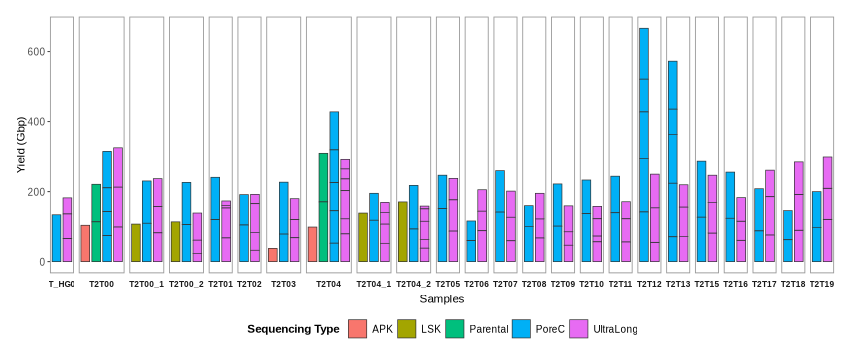

In [8]:
# Plot 1 Flowcell yield per type
p1_w = 7.16
p1_h = 3

p_flowcell_qc <- ggplot(flowcell_stats, aes(x = sequencing_type, y = yield / 1e9, fill = sequencing_type, group = flowcell_id)) + 
    geom_bar(stat = "identity", position = "stack", width = 0.8, color = "grey20", linewidth = 0.2) +
    facet_grid(. ~ dataset, scales = "free_x", space = "free_x", switch = "x") +
    theme(
        strip.background = element_blank(),
        strip.text = element_text(size = 5),
        strip.placement = "outside",
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        panel.spacing.x = unit(0.2, "lines"),
        panel.grid = element_blank(),
        legend.position = "bottom",
        panel.border = element_rect(color = "grey60", fill = NA, linewidth = 0.5),
    ) +
    labs(x = "Samples", y = "Yield (Gbp)", fill = "Sequencing Type")


options(repr.plot.width = p1_w, repr.plot.height = p1_h)
p_flowcell_qc
ggsave("../../doc/figures/flowcell_qc.png", plot = p_flowcell_qc, width = p1_w, height = p1_h)
ggsave("../../doc/figures/flowcell_qc.pdf", plot = p_flowcell_qc, width = p1_w, height = p1_h)

In [7]:
# Export flowcell stats to a table
write_tsv(flowcell_stats, "../../doc/tables/flowcell_stats.tsv")